# Customer Churn Prediction Project — Week 1
## Machine Learning Problem Framing & Data Understanding

**Client:** ABC Communications Ltd
**Programme:** AnalystLab Africa — Machine Learning Internship
**Prepared by:** Junior Machine Learning Engineer

This notebook covers:
1. Dataset loading and inspection
2. Data quality checks (types, missing values, duplicates)
3. Problem framing (target variable, features, task type)
4. Exploratory Data Analysis (3 bar charts, 2 histograms, 1 correlation heatmap)
5. Summary of findings for model planning


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Dataset Inspection

### 1.1 Data types and structure

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 1.2 Missing values

`TotalCharges` is stored as text (`object`) and contains blank entries that pandas does not flag as `NaN` by default. We convert it to numeric and re-check.

In [3]:
# TotalCharges should be numeric; blanks become NaN on coercion
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

print("\nRows with missing TotalCharges:")
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


Missing values per column:
TotalCharges    11
dtype: int64

Rows with missing TotalCharges:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


**Observation:** All 11 missing `TotalCharges` values belong to customers with `tenure = 0`, i.e. brand-new customers who have not yet been billed a full cycle. This is not random missingness — it is explained by tenure and should be imputed as `0` (or `MonthlyCharges * tenure`) rather than dropped, since these customers still carry a `Churn` label.

In [4]:
# Duplicate check
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())


Fully duplicated rows: 0
Duplicate customerIDs: 0


### 1.3 Target variable distribution

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(2))


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Observation:** The dataset is imbalanced — about 73.5% of customers did not churn (`No`) versus 26.5% who did (`Yes`). This has direct implications for model choice and evaluation metrics (see Section 4).

## 2. Problem Framing

- **Business problem:** ABC Communications Ltd wants to identify customers who are likely to churn *before* they leave, so retention teams can intervene proactively.
- **Target variable:** `Churn` (binary: Yes / No)
- **Task type:** Binary **classification**, not regression, since the target is a categorical label.
- **Input features:** All columns except `customerID` (an identifier with no predictive value) and `Churn` itself — demographic (gender, SeniorCitizen, Partner, Dependents), account (tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges), and service usage (PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) fields.

## 3. Exploratory Data Analysis

### 3.1 Bar Chart — Churn by Contract Type

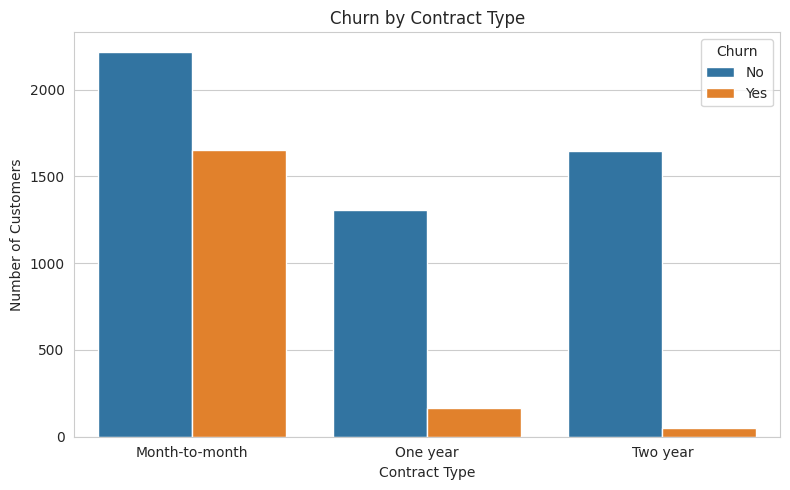

In [6]:
fig, ax = plt.subplots()
sns.countplot(data=df, x='Contract', hue='Churn', order=['Month-to-month','One year','Two year'], ax=ax)
ax.set_title('Churn by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()


### 3.2 Bar Chart — Churn by Internet Service

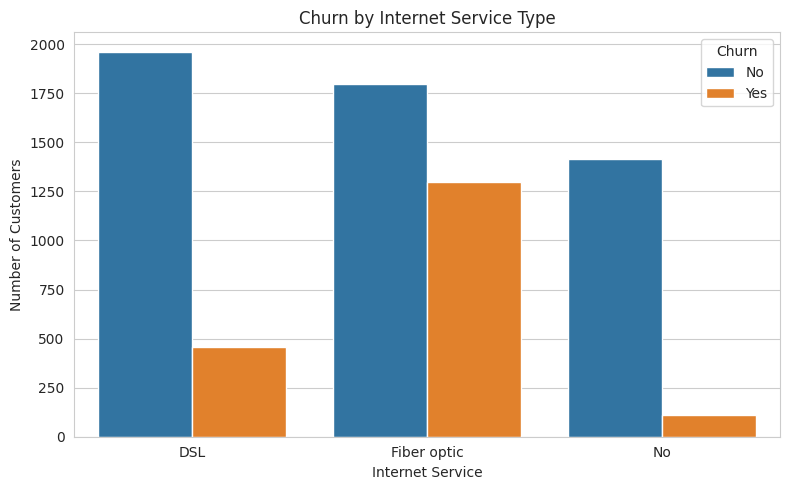

In [7]:
fig, ax = plt.subplots()
sns.countplot(data=df, x='InternetService', hue='Churn', ax=ax)
ax.set_title('Churn by Internet Service Type')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()


### 3.3 Bar Chart — Churn by Payment Method

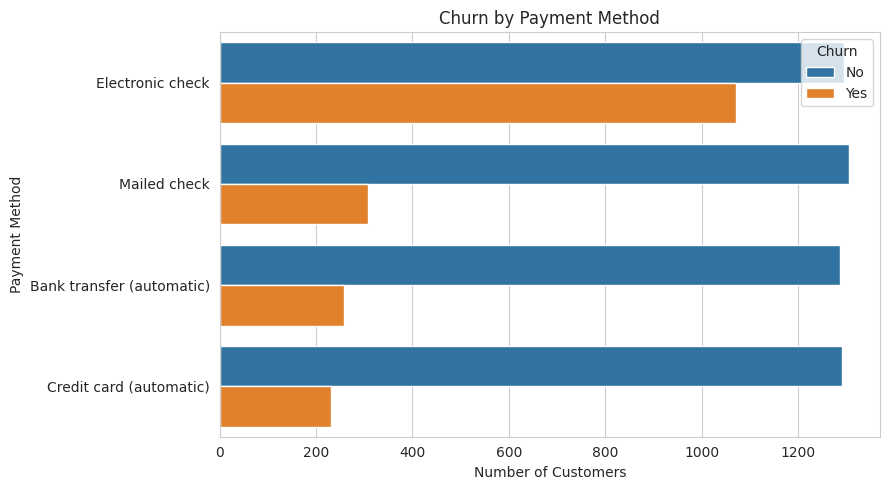

In [8]:
fig, ax = plt.subplots(figsize=(9,5))
sns.countplot(data=df, y='PaymentMethod', hue='Churn', ax=ax)
ax.set_title('Churn by Payment Method')
ax.set_xlabel('Number of Customers')
ax.set_ylabel('Payment Method')
plt.tight_layout()
plt.show()


### 3.4 Histogram — Tenure Distribution

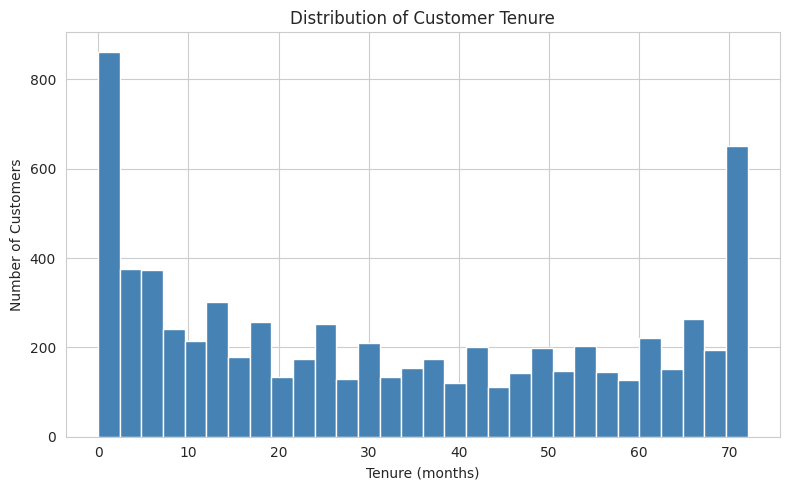

In [9]:
fig, ax = plt.subplots()
ax.hist(df['tenure'], bins=30, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Customer Tenure')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()


### 3.5 Histogram — Monthly Charges Distribution

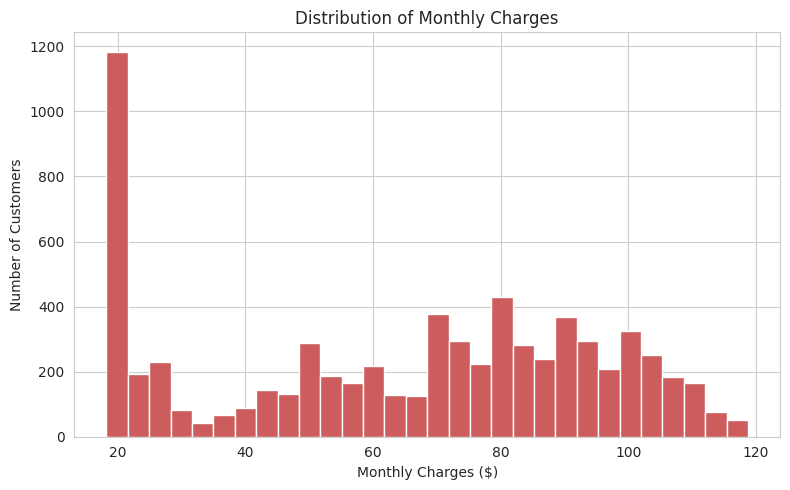

In [10]:
fig, ax = plt.subplots()
ax.hist(df['MonthlyCharges'], bins=30, color='indianred', edgecolor='white')
ax.set_title('Distribution of Monthly Charges')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()


### 3.6 Correlation Heatmap — Numeric Features

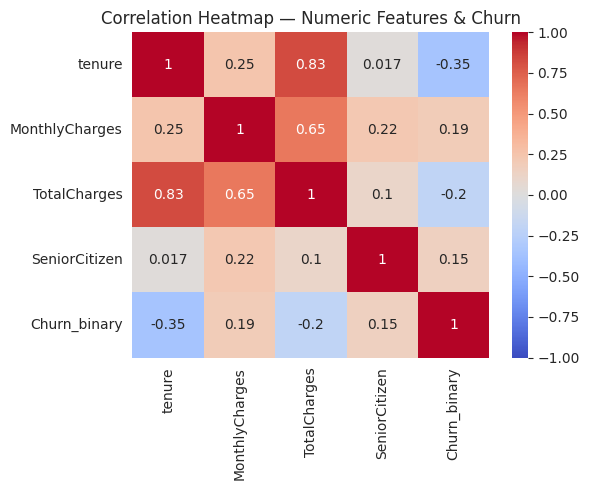

In [11]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
numeric_df['Churn_binary'] = df['Churn'].map({'No': 0, 'Yes': 1})

corr = numeric_df.corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features & Churn')
plt.tight_layout()
plt.show()


**Key EDA takeaways:**
- Month-to-month contracts churn far more than one- or two-year contracts — contract length looks like a strong predictor.
- Fiber optic internet customers churn more than DSL or no-internet customers.
- Electronic check payers churn more than customers on automatic bank transfer or credit card payments.
- Tenure is right-skewed with a large spike of very new customers (high churn risk) and a smaller spike near 70+ months (loyal customers).
- Monthly charges are bimodal, roughly clustered around $20 and $70–90.
- Tenure is negatively correlated with churn, while monthly charges are positively correlated with churn — consistent with the bar charts above.


## 4. Model Planning Notes

See the accompanying **Machine Learning Proposal** document for full detail on recommended algorithms, evaluation metrics, and preprocessing strategy. In summary:

- **Task:** Binary classification
- **Candidate algorithms:** Logistic Regression (baseline/interpretable), Random Forest, Gradient Boosting (XGBoost/LightGBM); KNN and SVM as secondary comparisons
- **Evaluation metrics:** Precision, Recall, F1-score, ROC-AUC (accuracy alone is misleading given ~73/27 class imbalance)
- **Preprocessing:** Impute the 11 missing `TotalCharges` values, one-hot encode categorical features, scale numeric features, stratified train/test split, and address class imbalance via class weighting or resampling (e.g. SMOTE)